
# 🩻 Hybrid Quantum-Classical Chest X-Ray Classification

### IBM Qiskit Fall Fest 2026 — Track 08

This notebook demonstrates the **frozen final inference pipeline** of our
hybrid quantum-classical diagnostic system.

**Pipeline**

`Chest X-ray → ResNet-18 → 512D features → PCA-8 → 8-Qubit VQC → Diagnosis`

> **Important:** The ResNet-18 representation, PCA transformation, and VQC
> training were completed during the experiment. This notebook performs
> inference using those frozen experimental artifacts; it does not retrain
> the model.


## 1. Environment & Imports

In [1]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import qiskit
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit_machine_learning.neural_networks import SamplerQNN

print("Qiskit:", qiskit.__version__)


Qiskit: 2.5.2


In [2]:

# All paths are relative to the project structure.
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

TEST_CSV = os.path.join(ROOT, "demo_data", "test.csv")
TRAIN_LABELS = os.path.join(ROOT, "demo_data", "train_labels.npy")
TEST_LABELS = os.path.join(ROOT, "demo_data", "test_labels.npy")

TRAIN_PCA = os.path.join(
    ROOT, "demo_data", "pca8", "train_pca.npy"
)

TEST_PCA = os.path.join(
    ROOT, "demo_data", "pca8", "test_pca.npy"
)

WEIGHTS = os.path.join(
    ROOT, "quantum_results",
    "cp09b_direct_trained_weights.npy"
)

DEMO_IMAGE = os.path.join(
    ROOT, "demo_assets", "Normal (39).jpg"
)

print("Demo files configured.")


Demo files configured.



## 2. Load the Frozen Experimental Representation

The original dataset contained 9,209 X-ray images.

For the final experiment:

- Train: **6,445**
- Validation: **1,381**
- Test: **1,382**

The frozen PCA representation contains **8 features**, corresponding to
the 8 qubits used by the VQC.


In [3]:

test_df = pd.read_csv(TEST_CSV)

y_train = np.load(TRAIN_LABELS)
y_test = np.load(TEST_LABELS)

X_train = np.load(TRAIN_PCA)
X_test = np.load(TEST_PCA)

print("Training PCA shape:", X_train.shape)
print("Test PCA shape:", X_test.shape)
print("Test CSV rows:", len(test_df))


Training PCA shape: (6445, 8)
Test PCA shape: (1382, 8)
Test CSV rows: 1382



## 3. Example Chest X-Ray

This is an actual image from the test set used in the experiment.


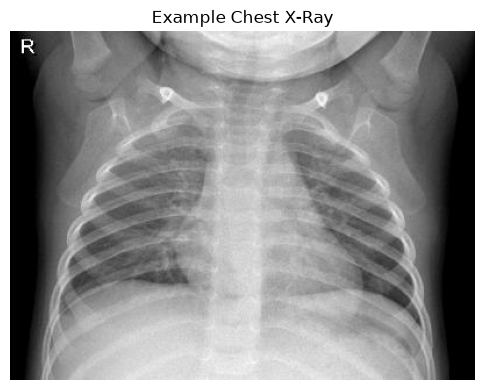

Dataset label for this demo image: Normal


In [4]:

img = Image.open(DEMO_IMAGE).convert("RGB")

plt.figure(figsize=(6, 6))
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.title("Example Chest X-Ray")
plt.show()

print("Dataset label for this demo image: Normal")



## 4. Hybrid Quantum-Classical Architecture

### Classical stage

The X-ray is represented using a **frozen pretrained ResNet-18**.
Its output is reduced from 512 dimensions to 8 dimensions using PCA.

### Quantum stage

The resulting 8-dimensional vector is encoded into an **8-qubit
variational quantum circuit**.

The VQC contains:

- 8 qubits
- 2 trainable layers
- Ry/Rz trainable rotations
- CX ladder entanglement
- data re-uploading
- 32 trainable parameters


## 5. Prepare the Quantum Input

In [5]:

# Reproduce the exact balanced training subset used during VQC training.
rng = np.random.default_rng(42)

selected_indices = []

for class_id in range(4):
    class_indices = np.where(y_train == class_id)[0]
    chosen = rng.choice(class_indices, size=50, replace=False)
    selected_indices.extend(chosen)

X_train_balanced = X_train[selected_indices]

# Min-max scaling based ONLY on the balanced quantum training subset.
train_min = X_train_balanced.min(axis=0)
train_max = X_train_balanced.max(axis=0)

def scale_to_pi(X):
    return (
        (X - train_min)
        / (train_max - train_min)
        * (2 * np.pi)
        - np.pi
    )

X_test_scaled = scale_to_pi(X_test)

x_sample = X_test_scaled[0]

print("Balanced quantum training samples:", len(X_train_balanced))
print("Samples per class: 50")
print("Quantum input dimensions:", X_test_scaled.shape[1])
print("First quantum input:")
print(np.round(x_sample, 4))


Balanced quantum training samples: 200
Samples per class: 50
Quantum input dimensions: 8
First quantum input:
[ 1.0036 -1.3807 -0.2351 -0.6966 -1.1532 -0.8094  0.7205 -0.0076]



## 6. Build the 8-Qubit Variational Quantum Circuit

This is the same architecture used for the frozen CP09-B experiment.


In [6]:

N_QUBITS = 8
N_LAYERS = 2
N_PARAMS = 32

x = ParameterVector("x", N_QUBITS)
theta = ParameterVector("theta", N_PARAMS)

qc = QuantumCircuit(N_QUBITS)

# Initial data encoding
for i in range(N_QUBITS):
    qc.ry(x[i], i)

# Trainable VQC layers
idx = 0

for layer in range(N_LAYERS):

    for q in range(N_QUBITS):
        qc.ry(theta[idx], q)
        idx += 1

        qc.rz(theta[idx], q)
        idx += 1

    # CX ladder
    for q in range(N_QUBITS - 1):
        qc.cx(q, q + 1)

    # Data re-uploading
    for q in range(N_QUBITS):
        qc.ry(x[q], q)

qc.measure_all()

print("Qubits:", N_QUBITS)
print("Trainable parameters:", N_PARAMS)
print("Layers:", N_LAYERS)
print("Circuit depth:", qc.depth())
print("Gate count:", len(qc.data))


Qubits: 8
Trainable parameters: 32
Layers: 2
Circuit depth: 17
Gate count: 79


### Quantum Circuit

In [7]:

qc.draw("mpl", fold=-1)
plt.show()



## 7. Create the Qiskit SamplerQNN

The measured computational basis states are mapped into four diagnostic
classes using:

`state % 4`


In [8]:

def interpret_state(state):
    return state % 4

qnn = SamplerQNN(
    circuit=qc,
    input_params=x,
    weight_params=theta,
    interpret=interpret_state,
    output_shape=4
)

print("SamplerQNN created successfully.")


SamplerQNN created successfully.



## 8. Load the Frozen VQC Parameters


In [9]:

weights = np.load(WEIGHTS)

print("Loaded weight vector:", weights.shape)
print("Number of parameters:", len(weights))


Loaded weight vector: (32,)
Number of parameters: 32



## 9. Run Quantum Inference

Now the actual frozen VQC performs inference on the selected test
X-ray representation.


In [10]:

probs = qnn.forward(
    x_sample.reshape(1, -1),
    weights
)[0]

prediction = int(np.argmax(probs))

class_names = [
    "COVID-19",
    "Normal",
    "Pneumonia-Bacterial",
    "Pneumonia-Viral"
]

print("Predicted class:", class_names[prediction])
print("True class: Normal")

print("\nClass probabilities:")
for name, probability in zip(class_names, probs):
    print(f"{name:22s}: {probability:.4f}")


Predicted class: Pneumonia-Viral
True class: Normal

Class probabilities:
COVID-19              : 0.1798
Normal                : 0.2803
Pneumonia-Bacterial   : 0.2125
Pneumonia-Viral       : 0.3274


### Quantum Prediction Probabilities

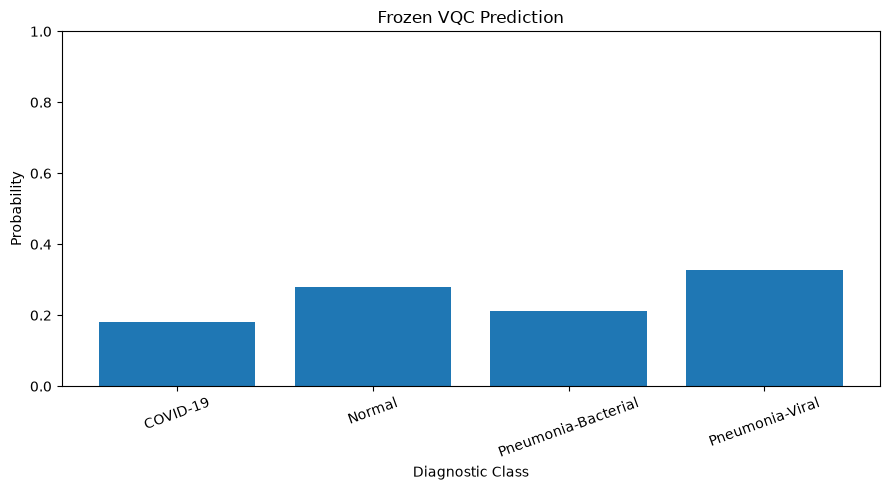

In [11]:

plt.figure(figsize=(9, 5))

plt.bar(class_names, probs)

plt.ylabel("Probability")
plt.xlabel("Diagnostic Class")
plt.title("Frozen VQC Prediction")
plt.ylim(0, 1)

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()



## 10. Frozen Experimental Results

The following values are the **frozen results from the completed
experiment**. They are not newly trained or optimized in this notebook.


In [12]:

results = pd.DataFrame({
    "Model": [
        "Classical PCA-8 baseline",
        "Fair classical baseline (200 samples)",
        "8-Qubit VQC"
    ],
    "Accuracy": [
        0.7793,
        0.7373,
        0.3495
    ],
    "Balanced Accuracy": [
        0.7480,
        0.7400,
        0.3103
    ],
    "Macro F1": [
        0.7465,
        0.7252,
        0.3058
    ],
    "AUC-ROC": [
        0.9293,
        0.9137,
        np.nan
    ]
})

results


,Model,Accuracy,Balanced Accuracy,Macro F1,AUC-ROC
0,Classical PCA-8 baseline,0.7793,0.7480,0.7465,0.9293
1,Fair classical baseline (200 samples),0.7373,0.7400,0.7252,0.9137
2,8-Qubit VQC,0.3495,0.3103,0.3058,NaN



### Classical vs Quantum Performance


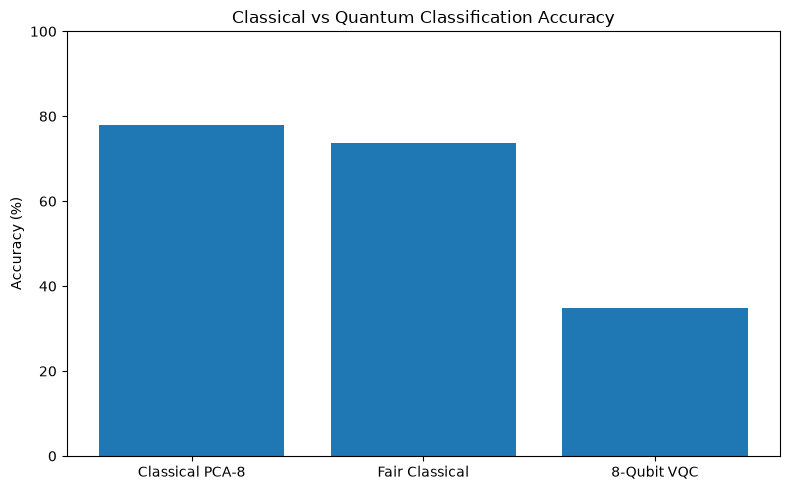

In [13]:

comparison = pd.DataFrame({
    "Model": [
        "Classical PCA-8",
        "Fair Classical",
        "8-Qubit VQC"
    ],
    "Accuracy": [
        77.93,
        73.73,
        34.95
    ]
})

plt.figure(figsize=(8, 5))
plt.bar(comparison["Model"], comparison["Accuracy"])

plt.ylabel("Accuracy (%)")
plt.title("Classical vs Quantum Classification Accuracy")
plt.ylim(0, 100)

plt.tight_layout()
plt.show()



## 11. Noise & Error-Mitigation Experiments

Noise experiments were performed on a balanced 100-sample test subset.

### Results

| Configuration | Accuracy |
|---|---:|
| Ideal | 33% |
| Depolarizing noise | 33% |
| Thermal noise | 33% |

The tested noise models did **not produce a substantial change** in
accuracy for this configuration.

Zero-noise extrapolation (ZNE) also did not improve the result.


In [14]:

noise_results = pd.DataFrame({
    "Configuration": [
        "Ideal",
        "Depolarizing noise",
        "Thermal noise",
        "ZNE"
    ],
    "Accuracy": [
        0.33,
        0.33,
        0.33,
        0.28
    ]
})

noise_results


,Configuration,Accuracy
0,Ideal,0.33
1,Depolarizing noise,0.33
2,Thermal noise,0.33
3,ZNE,0.28



## 12. Conclusion

### What we demonstrated

✅ A complete hybrid classical-quantum diagnostic pipeline  
✅ Frozen ResNet-18 image representation  
✅ PCA compression to an 8-dimensional quantum input  
✅ An 8-qubit trainable VQC implemented using Qiskit  
✅ Actual inference using frozen experimental parameters  
✅ Noise and ZNE experiments  

### What the experiment showed

The current VQC **did not outperform the classical baselines**.

The fair comparison was:

**Fair classical baseline:** 73.73% accuracy  
**8-qubit VQC:** 34.95% accuracy

Therefore, we **do not claim quantum advantage**.

This result is important because it provides an honest experimental assessment
of the current quantum approach and identifies clear directions for future
work.

### Future work

- Larger quantum training budgets
- Better quantum feature maps
- More expressive ansätze
- Hardware execution
- Improved noise mitigation
- Patient-level splitting where metadata is available
- Larger and clinically validated datasets



---

### Reproducibility Note

This notebook is a **demo/inference notebook**, not the complete research
pipeline.

The large raw dataset and intermediate ResNet-18 features are intentionally
excluded from the demo package.

All displayed quantum predictions use the frozen CP09-B VQC parameters
produced during the completed experiment.
